# Two-Photon Pulse

This example demonstrates how to optimize a CZ gate if the qubit state $|1\rangle$ is coupled to the Rydberg state $|r\rangle$ via an intermediate state $|e\rangle$. The example reproduces the nearly time-optimal gate from [Evered et al. (2023), Nature 622, 268-272 (2023)](https://doi.org/10.1038/s41586-023-06481-y).

In [1]:
# %pip install -q --progress-bar off rydopt # Uncomment for installation on Colab

import rydopt as ro
import numpy as np
import jax.numpy as jnp

First, we create the target gate.

In [2]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=450, decay=0)

We then implement the phase ansatz function from the publication.

In [3]:
def evered_phase(
    t: jnp.ndarray | float, _duration: float, ansatz_params: jnp.ndarray
) -> jnp.ndarray:
    a, omega, phi0 = ansatz_params
    return a * jnp.cos(omega * t - phi0)

We use it and pre-defined constant ansatz functions to define a two-photon pulse ansatz. We first define the ansatz for the lower transition $|1\rangle \leftrightarrow |e\rangle$, then for the upper transition $|e\rangle \leftrightarrow |r\rangle$. We combine both ansatz objects in a `TwoPhotonPulseAnsatz`.

In [4]:
lower = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=evered_phase,
    rabi_ansatz=ro.pulses.const,
)
upper = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    rabi_ansatz=ro.pulses.const,
)
pulse_ansatz = ro.pulses.TwoPhotonPulseAnsatz(
    lower_transition=lower,
    upper_transition=upper,
    lower_param_counts=(1, 3, 1),
    decay=0,
)

As initial parameters, we use the values from the publication (we provide all values in units of $2\pi \times 1 \text{ MHz}$). The `initial_params` tuple contains the gate duration and parameters for the detuning/phase/rabi ansatz functions. Each parameter array is packed as `[*lower_transition_params, *upper_transition_params]`. The parameter `lower_param_counts` specifies how many entries per parameter array belong to the lower transition, see above.

In [5]:
omega_l = 237
omega_u = 303
detuning_l = 7.8e3
detuning_u = -detuning_l - (omega_l**2 - omega_u**2) / (4 * detuning_l)

initial_params = (
    1.215 * 2 * np.pi / 4.6,
    [detuning_l, detuning_u],
    [2 * np.pi * 0.1122, 1.0431 * 4.6, -0.7318],
    [omega_l, omega_u],
)

We assume the detunings and Rabi frequencies as fixed and tune the other parameters to optimize the gate fidelity.

In [6]:
fixed_initial_params = (False, [True, True], [False, False, False], [True, True])
result = ro.optimization.optimize(
    gate, pulse_ansatz, initial_params, fixed_initial_params, num_steps=200, tol=1e-7
)

Started optimization using 1 process



proc00:   0%|                                                                                                 …


=== Optimization finished using Adam ===

Runtime: 5.129 seconds
Gates with infidelity below tol=1.0e-07: 1

Optimized gate:
> infidelity <= tol
> parameters = (1.6590980487451654, [ 7800.         -7798.85769231], [ 0.69712093  4.83123026 -0.70451509], [237. 303.])
> duration = 1.6590980487451654


We plot the optimized effective two-photon pulse.

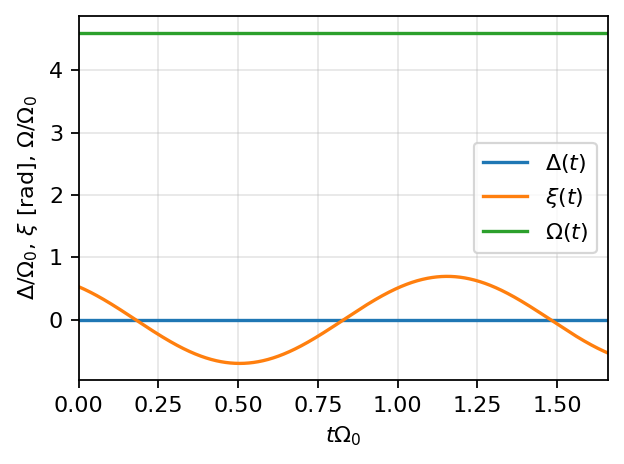

In [8]:
ro.characterization.plot_pulse(pulse_ansatz, result.params);

Finally, we compare the resulting gate duration against the result from the publication.

In [9]:
duration = result.params[0]
rabi_eff = abs(pulse_ansatz.evaluate_pulse_functions(0, result.params)[2].real)
print(f"Gate duration (Omega*T / 2pi): {duration * rabi_eff / (2 * np.pi):.3f}")
assert np.allclose(duration * rabi_eff / (2 * np.pi), 1.215, rtol=1e-3)

Gate duration (Omega*T / 2pi): 1.216


And calculate the infidelity resulting from the finite lifetime of the intermediate state.

In [10]:
pulse_ansatz_with_decay = ro.pulses.TwoPhotonPulseAnsatz(
    lower_transition=lower,
    upper_transition=upper,
    lower_param_counts=(1, 3, 1),
    decay=1 / (2 * np.pi * 110e-3),
)
infidelity = abs(
    1 - ro.simulation.average_gate_fidelity(gate, pulse_ansatz_with_decay, result.params)
)
print(f"Average gate infidelity due to intermediate state decay: {infidelity:.3%}")

Average gate infidelity due to intermediate state decay: 0.015%
